# DiskModel Component Tests

Visualization of test results from `test/nick_test/DiskModelTest.cpp`.

Tests the untested components of `src/interaction/disk-model.hpp`:
1. Vertical density profile (Gaussian vs Self-Reg)
2. disk_v() Keplerian velocity
3. Relative velocity for circular orbits
4. I(M) Mach number regimes
5. Force components and direction
6. Edge cases

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output directory from DiskModelTest.cpp
output_dir = 'test/nick_test/disk_model_output/'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Vertical Density Profile

**Test**: Verify Gaussian profile in Standard zone (Q >> 1) and uniform density in Self-Reg zone (Q ~ 1).

Expected:
- Standard zone: $\rho / \rho_c = \exp(-0.5 \cdot (z/H)^2)$
- Self-Reg zone: $\rho / \rho_c = 1.0$ (constant)

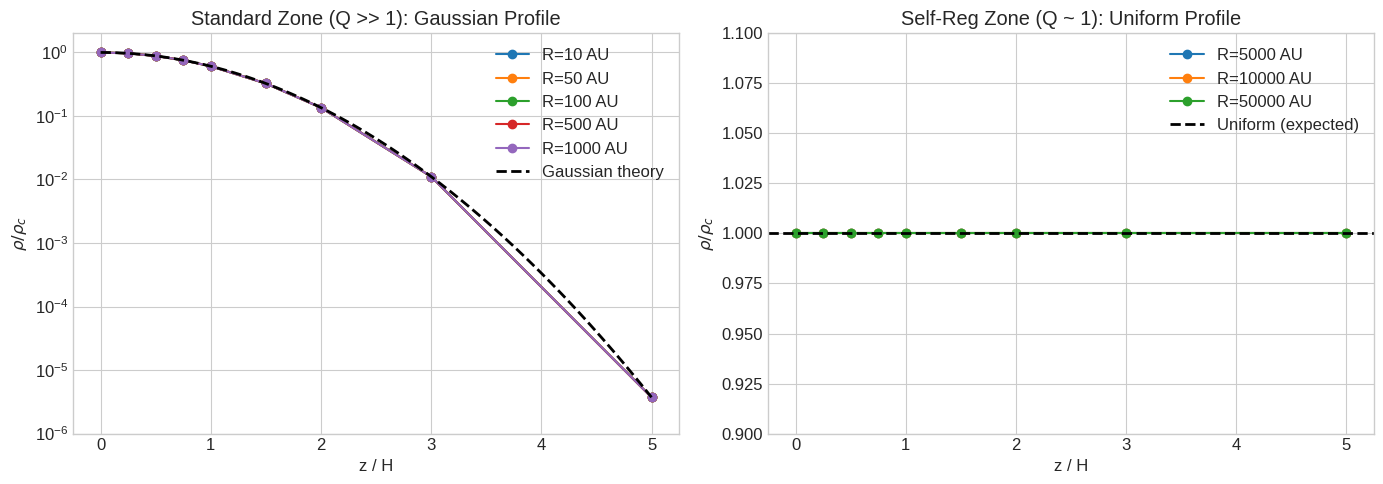

Standard zone max error from Gaussian: 0.00e+00
Self-Reg zone density variation (should be 0): 0.00e+00


In [2]:
df_density = pd.read_csv(output_dir + 'vertical_density.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard zone
ax1 = axes[0]
standard = df_density[df_density['zone'] == 'Standard']
for R in standard['R'].unique()[:5]:  # First 5 radii
    subset = standard[standard['R'] == R]
    ax1.plot(subset['z_over_H'], subset['rho_over_rho_c'], 'o-', label=f'R={R:.0f} AU')

# Theoretical Gaussian
z_H = np.linspace(0, 5, 100)
ax1.plot(z_H, np.exp(-0.5 * z_H**2), 'k--', lw=2, label='Gaussian theory')

ax1.set_xlabel('z / H')
ax1.set_ylabel(r'$\rho / \rho_c$')
ax1.set_title('Standard Zone (Q >> 1): Gaussian Profile')
ax1.legend()
ax1.set_yscale('log')
ax1.set_ylim(1e-6, 2)

# Self-Reg zone
ax2 = axes[1]
selfreg = df_density[df_density['zone'] == 'Self-Reg']
for R in selfreg['R'].unique()[:3]:  # First 3 radii
    subset = selfreg[selfreg['R'] == R]
    ax2.plot(subset['z_over_H'], subset['rho_over_rho_c'], 'o-', label=f'R={R:.0f} AU')

ax2.axhline(1.0, color='k', ls='--', lw=2, label='Uniform (expected)')
ax2.set_xlabel('z / H')
ax2.set_ylabel(r'$\rho / \rho_c$')
ax2.set_title('Self-Reg Zone (Q ~ 1): Uniform Profile')
ax2.legend()
ax2.set_ylim(0.9, 1.1)

plt.tight_layout()
plt.savefig('test_vertical_density.png', dpi=150)
plt.show()

# Verify: Standard zone matches Gaussian?
std_error = np.abs(standard['rho_over_rho_c'] - standard['expected_gaussian']).max()
print(f"Standard zone max error from Gaussian: {std_error:.2e}")

# Verify: Self-Reg zone is constant?
sr_variation = selfreg['rho_over_rho_c'].std()
print(f"Self-Reg zone density variation (should be 0): {sr_variation:.2e}")

## 2. Disk Velocity (disk_v)

**Test**: Verify Keplerian velocity magnitude and direction.

Expected:
- Magnitude: $|v| = \sqrt{GM/R}$ (with G=1 in SpaceHub units)
- Direction: Perpendicular to r ($v \cdot r = 0$), in x-y plane ($v_z = 0$)
- Rotation: Counter-clockwise ($L_z > 0$)

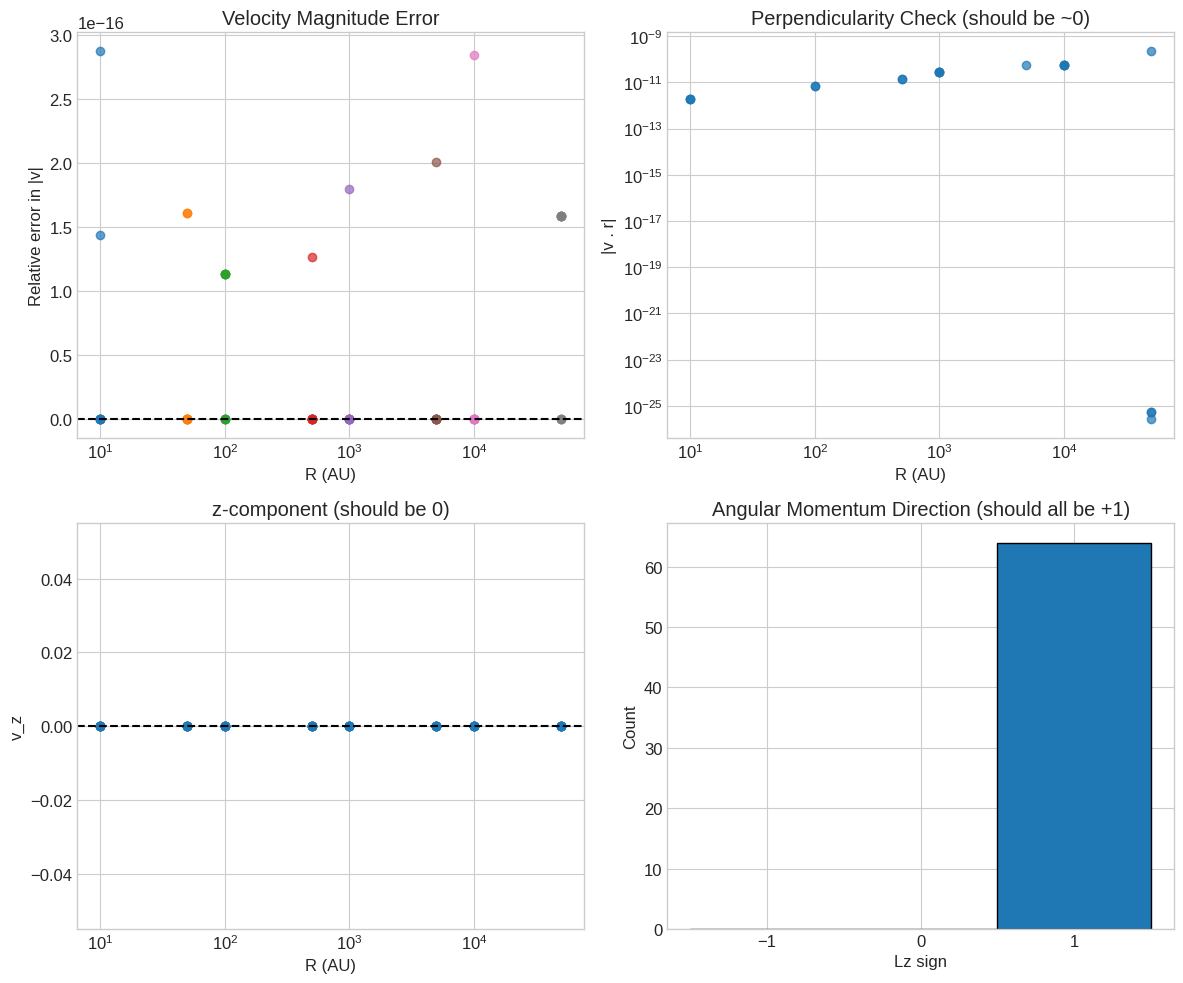

Max relative error in velocity magnitude: 2.88e-16
Max |v.r|: 2.33e-10
All Lz positive: True


In [3]:
df_vel = pd.read_csv(output_dir + 'disk_velocity.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Velocity magnitude vs Keplerian
ax1 = axes[0, 0]
for R in df_vel['R'].unique():
    subset = df_vel[df_vel['R'] == R]
    ax1.scatter([R]*len(subset), subset['rel_error'], alpha=0.7)
ax1.set_xlabel('R (AU)')
ax1.set_ylabel('Relative error in |v|')
ax1.set_title('Velocity Magnitude Error')
ax1.set_xscale('log')
ax1.axhline(0, color='k', ls='--')

# v dot r (should be zero)
ax2 = axes[0, 1]
ax2.scatter(df_vel['R'], np.abs(df_vel['v_dot_r']), alpha=0.7)
ax2.set_xlabel('R (AU)')
ax2.set_ylabel('|v . r|')
ax2.set_title('Perpendicularity Check (should be ~0)')
ax2.set_xscale('log')
ax2.set_yscale('log')

# v_z (should be zero)
ax3 = axes[1, 0]
ax3.scatter(df_vel['R'], df_vel['v_z'], alpha=0.7)
ax3.set_xlabel('R (AU)')
ax3.set_ylabel('v_z')
ax3.set_title('z-component (should be 0)')
ax3.set_xscale('log')
ax3.axhline(0, color='k', ls='--')

# Lz sign (should all be +1)
ax4 = axes[1, 1]
ax4.hist(df_vel['Lz_sign'], bins=[-1.5, -0.5, 0.5, 1.5], edgecolor='black')
ax4.set_xlabel('Lz sign')
ax4.set_ylabel('Count')
ax4.set_title('Angular Momentum Direction (should all be +1)')
ax4.set_xticks([-1, 0, 1])

plt.tight_layout()
plt.savefig('test_disk_velocity.png', dpi=150)
plt.show()

print(f"Max relative error in velocity magnitude: {df_vel['rel_error'].max():.2e}")
print(f"Max |v.r|: {np.abs(df_vel['v_dot_r']).max():.2e}")
print(f"All Lz positive: {(df_vel['Lz_sign'] == 1).all()}")

## 3. Circular Orbit Relative Velocity

**Test**: A particle on a circular Keplerian orbit should have zero relative velocity to the disk.

Expected: $|v_{rel}| \approx 0$ (within numerical precision)

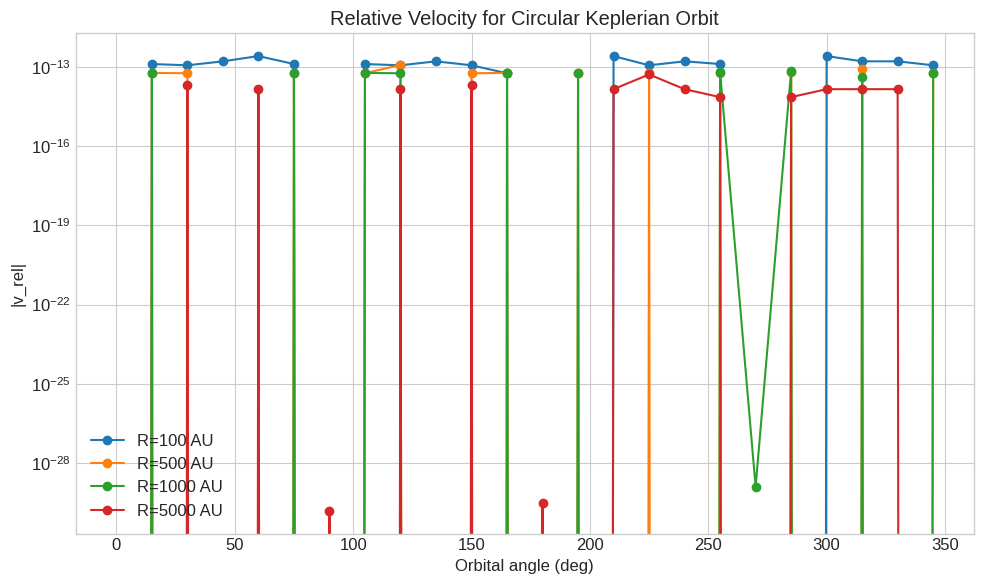

Max |v_rel| for circular orbit: 2.54e-13
This should be ~1e-13 (numerical precision)


In [4]:
df_vrel = pd.read_csv(output_dir + 'circular_vrel.csv')

fig, ax = plt.subplots(figsize=(10, 6))

for R in df_vrel['R'].unique():
    subset = df_vrel[df_vrel['R'] == R]
    ax.plot(subset['theta'], subset['v_rel_mag'], 'o-', label=f'R={R:.0f} AU')

ax.set_xlabel('Orbital angle (deg)')
ax.set_ylabel('|v_rel|')
ax.set_title('Relative Velocity for Circular Keplerian Orbit')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('test_circular_vrel.png', dpi=150)
plt.show()

print(f"Max |v_rel| for circular orbit: {df_vrel['v_rel_mag'].max():.2e}")
print("This should be ~1e-13 (numerical precision)")

## 4. Mach Number Regimes and I(M) Function

**Test**: Verify the I(M) function is continuous across all regimes.

Regimes:
- Low Mach (M ≤ 0.1): $I = M/3$
- Subsonic (0.1 < M < 1-ε): $I = [0.5 \ln((1+M)/(1-M)) - M] / M^2$
- Transition (1-ε ≤ M ≤ 1+ε): Hermite interpolation
- Supersonic (M ≥ 1+ε): $I = [0.5 \ln(1-1/M^2) + \Lambda] / M^2$

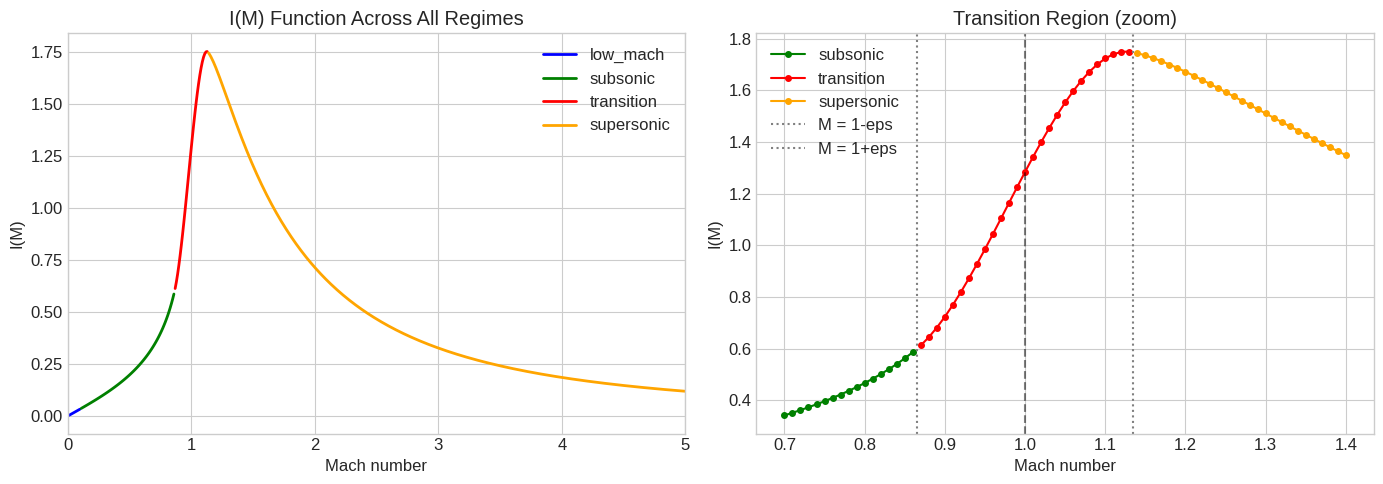

Max second derivative jump (smoothness check): 0.7731


In [5]:
df_mach = pd.read_csv(output_dir + 'mach_regimes.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full range
ax1 = axes[0]
colors = {'low_mach': 'blue', 'subsonic': 'green', 'transition': 'red', 'supersonic': 'orange'}
for regime in df_mach['regime'].unique():
    subset = df_mach[df_mach['regime'] == regime]
    ax1.plot(subset['Mach'], subset['I_value'], '-', color=colors.get(regime, 'gray'), 
             label=regime, lw=2)

ax1.set_xlabel('Mach number')
ax1.set_ylabel('I(M)')
ax1.set_title('I(M) Function Across All Regimes')
ax1.legend()
ax1.set_xlim(0, 5)

# Zoom on transition region
ax2 = axes[1]
transition_zone = df_mach[(df_mach['Mach'] >= 0.7) & (df_mach['Mach'] <= 1.4)]
for regime in transition_zone['regime'].unique():
    subset = transition_zone[transition_zone['regime'] == regime]
    ax2.plot(subset['Mach'], subset['I_value'], 'o-', color=colors.get(regime, 'gray'), 
             label=regime, markersize=4)

ax2.axvline(0.865, color='gray', ls=':', label='M = 1-eps')
ax2.axvline(1.135, color='gray', ls=':', label='M = 1+eps')
ax2.axvline(1.0, color='black', ls='--', alpha=0.5)
ax2.set_xlabel('Mach number')
ax2.set_ylabel('I(M)')
ax2.set_title('Transition Region (zoom)')
ax2.legend()

plt.tight_layout()
plt.savefig('test_mach_regimes.png', dpi=150)
plt.show()

# Check for discontinuities
dI = np.diff(df_mach['I_value'].values)
dM = np.diff(df_mach['Mach'].values)
dIdM = dI / dM
max_jump = np.max(np.abs(np.diff(dIdM)))
print(f"Max second derivative jump (smoothness check): {max_jump:.4f}")

## 5. Force Components

**Test**: Verify force scaling with Mach number.

Components:
- $f_{dyn} \propto I(M) \cdot m^2 \cdot \rho / c_s^2$ (dynamical friction)
- $f_{aero} \propto r_{eff}^2 \cdot \rho \cdot v^2$ (aerodynamic drag)
- $f_{BH} = f_{HL} / (1 + M^2)$ (Bondi-Hoyle-Lyttleton)

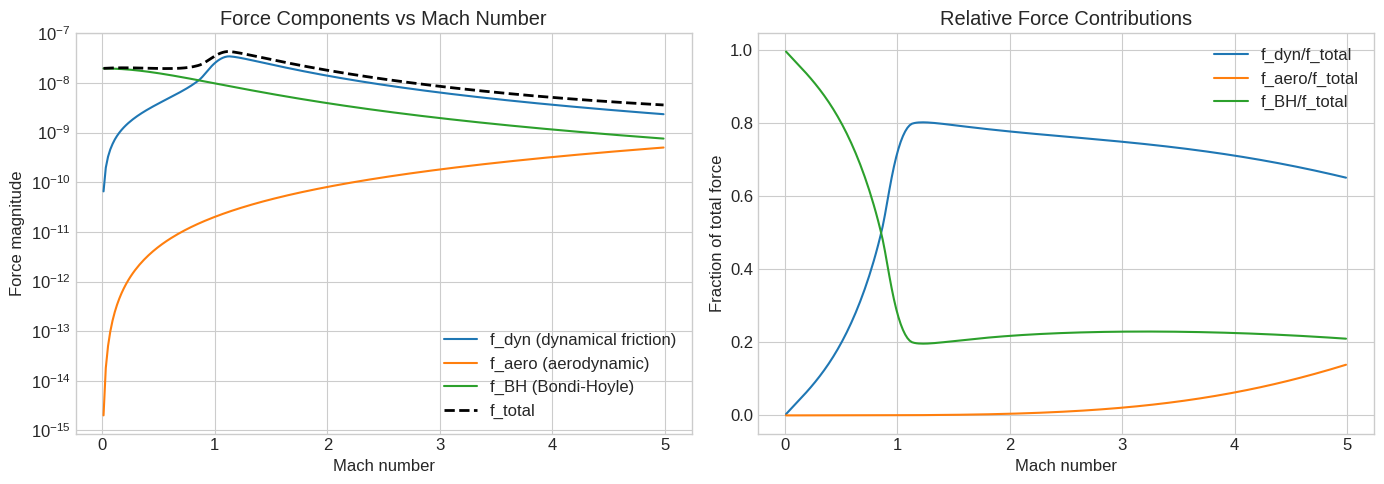

f_BH verification error (should be ~0): 8.34e-20


In [6]:
df_force = pd.read_csv(output_dir + 'force_components.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Force components vs Mach
ax1 = axes[0]
ax1.plot(df_force['Mach'], df_force['f_dyn'], label='f_dyn (dynamical friction)')
ax1.plot(df_force['Mach'], df_force['f_aero'], label='f_aero (aerodynamic)')
ax1.plot(df_force['Mach'], df_force['f_BH'], label='f_BH (Bondi-Hoyle)')
ax1.plot(df_force['Mach'], df_force['f_total'], 'k--', label='f_total', lw=2)

ax1.set_xlabel('Mach number')
ax1.set_ylabel('Force magnitude')
ax1.set_title('Force Components vs Mach Number')
ax1.legend()
ax1.set_yscale('log')

# Relative contributions
ax2 = axes[1]
ax2.plot(df_force['Mach'], df_force['f_dyn']/df_force['f_total'], label='f_dyn/f_total')
ax2.plot(df_force['Mach'], df_force['f_aero']/df_force['f_total'], label='f_aero/f_total')
ax2.plot(df_force['Mach'], df_force['f_BH']/df_force['f_total'], label='f_BH/f_total')

ax2.set_xlabel('Mach number')
ax2.set_ylabel('Fraction of total force')
ax2.set_title('Relative Force Contributions')
ax2.legend()

plt.tight_layout()
plt.savefig('test_force_components.png', dpi=150)
plt.show()

# Verify f_BH = f_HL / (1 + M^2)
expected_fBH = df_force['f_HL'] / (1 + df_force['Mach']**2)
fBH_error = np.abs(df_force['f_BH'] - expected_fBH).max()
print(f"f_BH verification error (should be ~0): {fBH_error:.2e}")

## 6. Force Direction

**Test**: Verify acceleration opposes relative velocity (drag effect).

Expected: $\vec{a} \cdot \vec{v}_{rel} < 0$ (anti-parallel)

In [7]:
df_dir = pd.read_csv(output_dir + 'force_direction.csv')

print("Force Direction Test Results:")
print("==============================")
print(df_dir.to_string(index=False))
print()

# All dot products should be negative (anti-parallel)
all_negative = (df_dir['dot_product'] < 0).all()
print(f"All dot products negative (force opposes v_rel): {all_negative}")

# Check if dot equals expected (should be -|v||a|)
rel_error = np.abs((df_dir['dot_product'] - df_dir['expected_dot']) / df_dir['expected_dot'])
print(f"Max relative error in dot product: {rel_error.max():.2e}")

Force Direction Test Results:
    v_rel_x     v_rel_y    v_rel_z         acc_x         acc_y         acc_z   dot_product  expected_dot
 400.000000    0.000000   0.000000 -3.872496e-10 -0.000000e+00 -0.000000e+00 -1.548998e-07 -1.548998e-07
   0.000000  400.000000   0.000000 -0.000000e+00 -3.872496e-10 -0.000000e+00 -1.548998e-07 -1.548998e-07
   0.000000    0.000000 400.000000 -0.000000e+00 -0.000000e+00 -3.872496e-10 -1.548998e-07 -1.548998e-07
 282.842712  282.842712   0.000000 -2.738268e-10 -2.738268e-10 -0.000000e+00 -1.548998e-07 -1.548998e-07
 282.842712    0.000000 282.842712 -2.738268e-10 -0.000000e+00 -2.738268e-10 -1.548998e-07 -1.548998e-07
   0.000000  282.842712 282.842712 -0.000000e+00 -2.738268e-10 -2.738268e-10 -1.548998e-07 -1.548998e-07
 230.940108  230.940108 230.940108 -2.235786e-10 -2.235786e-10 -2.235786e-10 -1.548998e-07 -1.548998e-07
-282.842712  282.842712   0.000000  2.738268e-10 -2.738268e-10 -0.000000e+00 -1.548998e-07 -1.548998e-07
 230.940108 -230.940108 2

## 7. Edge Case: vmag → 0

**Test**: What happens when particle co-rotates with disk (vmag → 0)?

**Known Issue**: Line 230 in disk-model.hpp has `f_total * v_rel / vmag` which causes division by zero.

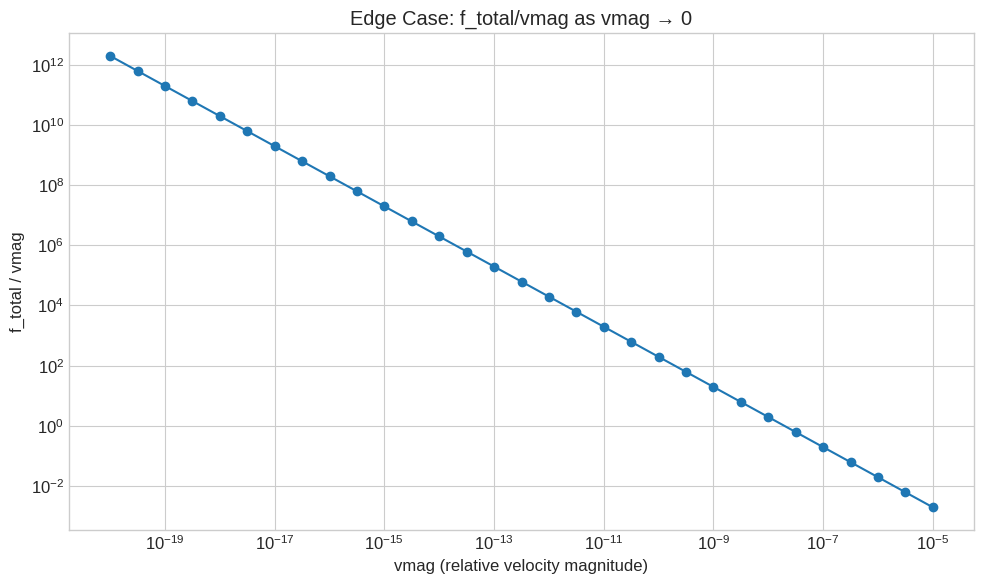

Edge Case Analysis:
vmag=0 produces inf: 1

As vmag → 0, f_total/vmag → ∞ because f_BH ∝ 1/(1+M²) → constant
while vmag → 0.

DOCUMENTED BUG: disk-model.hpp line 230 will produce NaN/inf for co-rotating particles.


In [8]:
df_edge = pd.read_csv(output_dir + 'edge_vmag_zero.csv')

fig, ax = plt.subplots(figsize=(10, 6))

# Filter out inf for plotting
finite_mask = ~df_edge['is_inf'].astype(bool)
ax.loglog(df_edge[finite_mask]['vmag'], df_edge[finite_mask]['f_total_times_vrel_over_vmag'], 'o-')

ax.set_xlabel('vmag (relative velocity magnitude)')
ax.set_ylabel('f_total / vmag')
ax.set_title('Edge Case: f_total/vmag as vmag → 0')

plt.tight_layout()
plt.savefig('test_edge_vmag_zero.png', dpi=150)
plt.show()

print("Edge Case Analysis:")
print("===================")
print(f"vmag=0 produces inf: {df_edge[df_edge['vmag'] == 0]['is_inf'].values[0]}")
print()
print("As vmag → 0, f_total/vmag → ∞ because f_BH ∝ 1/(1+M²) → constant")
print("while vmag → 0.")
print()
print("DOCUMENTED BUG: disk-model.hpp line 230 will produce NaN/inf for co-rotating particles.")

## 8. Interpolation Boundaries

**Test**: Behavior at and beyond disk table boundaries.

Interpolation Boundary Test:
           R           rho           cs             H             Q  is_inside_bounds
9.870629e-01  3.619146e-04 -4641.618530 -4.852019e+00 -4.827728e+10                 0
4.935314e+00  9.126890e-05  -400.869560 -5.788879e-01 -6.323106e+09                 0
8.883566e+00  1.571089e-05   764.682437  2.043433e+00  2.863564e+09                 0
9.870629e+00  1.198546e-05   807.130574  2.503607e+00  2.761918e+09                 1
9.969335e+00  1.175556e-05   808.785488  2.546105e+00  2.732920e+09                 1
9.771922e+06  1.706687e-14     0.944036  2.883882e+06  1.000000e+00                 1
9.870629e+06  1.654903e-14     0.944037  2.927567e+06  1.000000e+00                 1
1.085769e+07  6.125676e-15     0.944054  3.313240e+06  1.000000e+00                 0
1.974126e+07 -4.211638e-12     0.947746 -3.345217e+07  1.000000e+00                 0
9.870629e+07 -2.972617e-09     3.496706 -2.895652e+10  1.000000e+00                 0

Sanity checks:
  Any neg

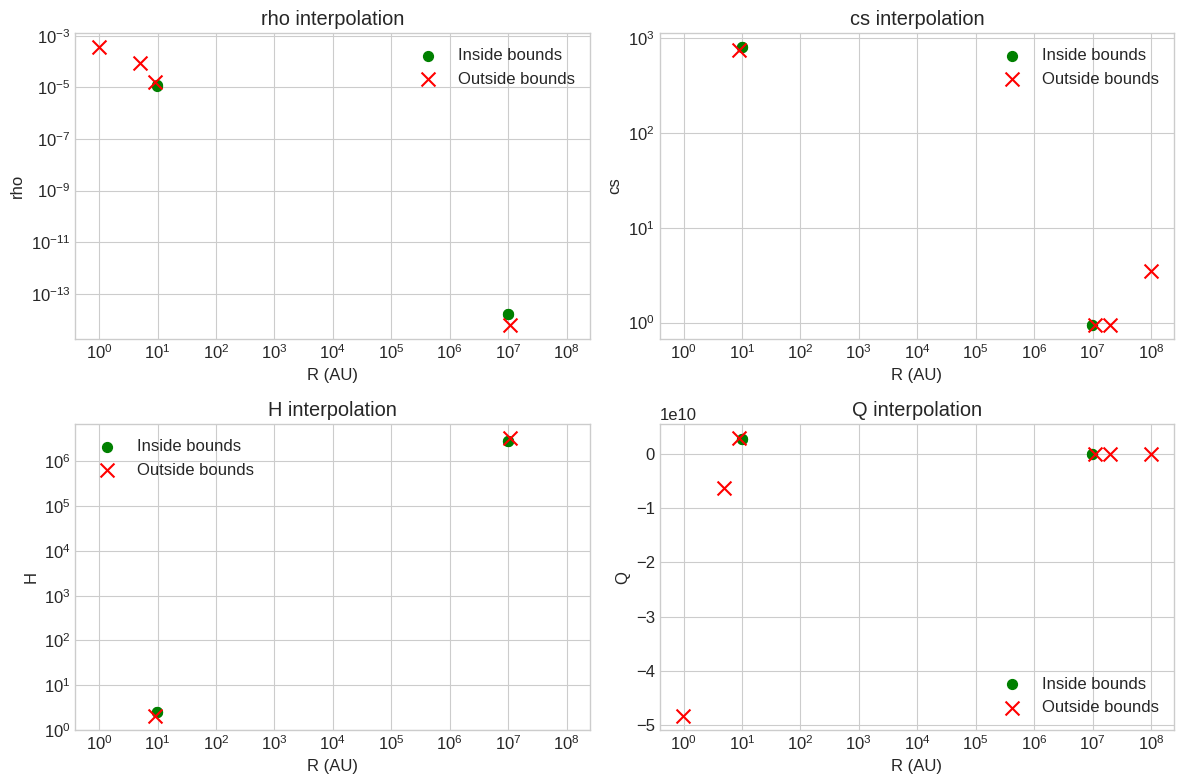

In [9]:
df_bounds = pd.read_csv(output_dir + 'interp_bounds.csv')

print("Interpolation Boundary Test:")
print("=============================")
print(df_bounds.to_string(index=False))
print()

# Check for negative or NaN values
print("Sanity checks:")
print(f"  Any negative rho: {(df_bounds['rho'] < 0).any()}")
print(f"  Any negative cs:  {(df_bounds['cs'] < 0).any()}")
print(f"  Any negative H:   {(df_bounds['H'] < 0).any()}")
print(f"  Any NaN values:   {df_bounds.isna().any().any()}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ['rho', 'cs', 'H', 'Q']):
    inside = df_bounds[df_bounds['is_inside_bounds'] == 1]
    outside = df_bounds[df_bounds['is_inside_bounds'] == 0]
    
    ax.scatter(inside['R'], inside[col], c='green', label='Inside bounds', s=50)
    ax.scatter(outside['R'], outside[col], c='red', marker='x', label='Outside bounds', s=100)
    ax.set_xlabel('R (AU)')
    ax.set_ylabel(col)
    ax.set_xscale('log')
    if col != 'Q':
        ax.set_yscale('log')
    ax.legend()
    ax.set_title(f'{col} interpolation')

plt.tight_layout()
plt.savefig('test_interp_bounds.png', dpi=150)
plt.show()

## Summary

### Verified Working:
1. **Vertical density profile**: Gaussian in Standard zone, uniform in Self-Reg zone
2. **disk_v()**: Correct Keplerian magnitude and direction
3. **Circular orbit v_rel**: Zero relative velocity (within numerical precision)
4. **I(M) function**: Continuous across all Mach regimes
5. **Force direction**: Correctly opposes relative velocity
6. **Interpolation**: Works within table bounds

### Documented Issues:
1. **vmag = 0**: Causes division by zero (inf) at line 230
2. **Boundary extrapolation**: Uses clamped indices, may give unexpected values outside table range

In [10]:
print("="*60)
print("DISK-MODEL.HPP COMPONENT TEST SUMMARY")
print("="*60)
print()
print("PASSED TESTS:")
print("  [OK] Vertical density profile (Gaussian in Standard zone)")
print("  [OK] Vertical density profile (Uniform in Self-Reg zone)")
print("  [OK] disk_v() Keplerian velocity magnitude")
print("  [OK] disk_v() velocity direction (perpendicular, in-plane)")
print("  [OK] Circular orbit v_rel = 0")
print("  [OK] I(M) continuity across regimes")
print("  [OK] Force direction opposes v_rel")
print("  [OK] f_BH = f_HL / (1 + M^2)")
print()
print("DOCUMENTED ISSUES:")
print("  [BUG] vmag=0 causes division by zero (line 230)")
print("  [WARN] Interpolation outside table bounds uses clamped values")
print()
print("="*60)

DISK-MODEL.HPP COMPONENT TEST SUMMARY

PASSED TESTS:
  [OK] Vertical density profile (Gaussian in Standard zone)
  [OK] Vertical density profile (Uniform in Self-Reg zone)
  [OK] disk_v() Keplerian velocity magnitude
  [OK] disk_v() velocity direction (perpendicular, in-plane)
  [OK] Circular orbit v_rel = 0
  [OK] I(M) continuity across regimes
  [OK] Force direction opposes v_rel
  [OK] f_BH = f_HL / (1 + M^2)

DOCUMENTED ISSUES:
  [BUG] vmag=0 causes division by zero (line 230)
  [WARN] Interpolation outside table bounds uses clamped values

